# 07 — Demo

Owner: VT

Clean demo notebook for the final presentation. Cherry-pick the strongest results.

(b) Demo notebook (07_demo.ipynb): a clean run-through for the presentation that loads a single trial, shows the SSVEP peak in PSD, runs each classifier, prints predictions. Useful for the live demo if Aayush wants one in the deck

# Demo Notebook: Single-Trial SSVEP Classification

This notebook provides a simple end-to-end demonstration of our SSVEP pipeline using one representative trial from Subject 1.

Workflow:

1. Load raw data  
2. Apply default preprocessing (continuous filtering + epoching)  
3. Select one clean trial using PSD peak strength  
4. Visualize the SSVEP spectral response  
5. Run multiple classifiers on the same trial  
6. Compare predictions

This notebook is intended for presentation and intuitive demonstration rather than full benchmarking.

In [6]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from ssvep import io, preprocessing, features, evaluation, viz, synthetic
from ssvep.classifiers import CCAClassifier

## 1. Load Dataset and Apply Default Preprocessing

Use the default 3-second pipeline:

- 50 Hz notch filter  
- 3–45 Hz bandpass  
- 0.25–3.25 s epoch window

In [7]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch

from ssvep import io, preprocessing

file_path = Path("../data/raw/subject_1_fvep_led_training_1.mat")

preset = preprocessing.PREPROCESSING_PRESETS["default_3s"]
print(preset)

# Load real file through io.py, but use raw continuous data for correct continuous-first filtering
ds = io.load_mat(file_path)
raw = ds["raw"]["continuous"]
fs = float(ds["fs"])
stim_freqs = ds["stim_freqs"]
ch_names = ds["ch_names"]

# Continuous-first filtering
filtered = preprocessing.filter_continuous(
    raw,
    fs,
    l_freq=preset["bandpass_range"][0],
    h_freq=preset["bandpass_range"][1],
    notch_hz=preset["notch_freqs"][0],
    verbose=False,
)

# Detect trial onsets and labels from trigger channel
trigger = filtered[9]
stim_on = trigger > 0
onsets = np.where(np.diff(stim_on.astype(int)) == 1)[0] + 1
labels_freq = trigger[onsets]

# Map frequency labels to class indices matching stim_freqs
freq_to_class = {freq: i for i, freq in enumerate(stim_freqs)}
y = np.array([freq_to_class[f] for f in labels_freq])

# Epoch filtered EEG rows only: CH2–CH9 = rows 1:9
X = preprocessing.epoch(
    filtered[1:9],
    onsets,
    fs,
    tmin=preset["tmin"],
    tmax=preset["tmax"],
)

print("X:", X.shape)
print("y:", y.shape)
print("stim freqs:", stim_freqs)
print("channels:", ch_names)

{'notch_freqs': (50.0,), 'bandpass_range': (3.0, 45.0), 'tmin': 0.25, 'tmax': 3.25}
X: (20, 8, 768)
y: (20,)
stim freqs: [ 9. 10. 12. 15.]
channels: ['PO7', 'PO3', 'POz', 'PO4', 'PO8', 'O1', 'Oz', 'O2']


## 2. Select a Representative Single Trial

Trials are ranked by target-frequency peak strength in the PSD.  
We choose a strong but non-extreme trial for demonstration.

In [8]:
def target_peak_score(trial, target_freq, fs):
    freqs, psd = welch(trial, fs=fs, nperseg=trial.shape[-1], axis=-1)
    mean_psd = psd.mean(axis=0)

    target_idx = np.argmin(np.abs(freqs - target_freq))
    target_power = mean_psd[target_idx]

    nearby = (freqs >= target_freq - 2) & (freqs <= target_freq + 2)
    exclude = np.abs(freqs - target_freq) < 0.5
    bg = mean_psd[nearby & ~exclude].mean()

    return target_power / bg

scores = []

for i in range(len(X)):
    true_freq = stim_freqs[y[i]]
    score = target_peak_score(X[i], true_freq, fs)
    scores.append({
        "trial": i,
        "true_freq": true_freq,
        "score": score,
    })

scores_df = pd.DataFrame(scores).sort_values("score", ascending=False)
scores_df.head(10)

,trial,true_freq,score
2,2,10.0,13.658298
7,7,9.0,5.568300
12,12,15.0,5.003844
14,14,10.0,3.454586
0,0,15.0,3.187250
4,4,15.0,3.075233
5,5,12.0,3.034079
3,3,9.0,2.874155
10,10,10.0,2.573235
6,6,10.0,2.033359


In [9]:
trial_idx = int(scores_df.iloc[1]["trial"])  # second-best, avoids strongest outlier
true_freq = stim_freqs[y[trial_idx]]

print("Selected trial:", trial_idx)
print("True frequency:", true_freq)
print("Peak score:", scores_df.iloc[1]["score"])

Selected trial: 7
True frequency: 9.0
Peak score: 5.568299597508458


### Trial 2 is too exceptional, which can look overly curated.

## 3. Visualize Single-Trial SSVEP Response

Plot the average PSD across channels.  
A clear peak near the target frequency indicates an SSVEP response.

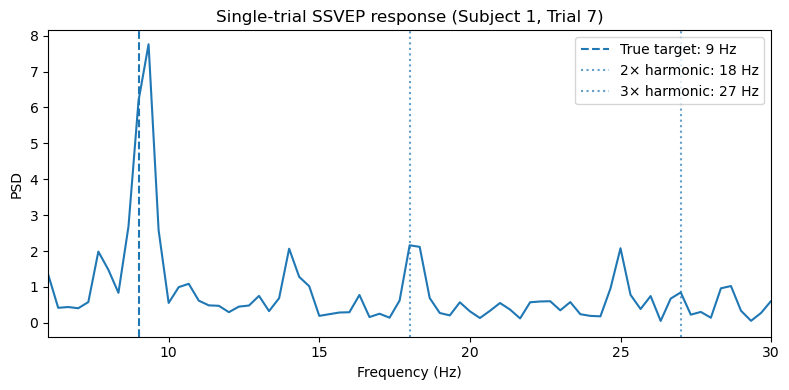

In [10]:
trial = X[trial_idx]

freqs, psd = welch(trial, fs=fs, nperseg=trial.shape[-1], axis=-1)
mean_psd = psd.mean(axis=0)

plt.figure(figsize=(8, 4))
plt.plot(freqs, mean_psd)
plt.axvline(true_freq, linestyle="--", label=f"True target: {true_freq:.0f} Hz")

# optional harmonics
for h in [2, 3]:
    harmonic = true_freq * h
    if harmonic <= 45:
        plt.axvline(harmonic, linestyle=":", alpha=0.7, label=f"{h}× harmonic: {harmonic:.0f} Hz")

plt.xlim(6, 30)
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")
plt.title("Single-trial SSVEP response (Subject 1, Trial 7)")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Run CCA Classifier

CCA compares EEG activity with sinusoidal reference signals at candidate stimulus frequencies.

In [11]:
from ssvep.classifiers.cca import CCAClassifier
import inspect

print(inspect.signature(CCAClassifier))
print(inspect.signature(CCAClassifier.predict))

(stim_freqs: 'Iterable[float]', fs: 'float', n_harmonics: 'int' = 2)
(self, X: 'np.ndarray') -> 'np.ndarray'


In [12]:
cca = CCAClassifier(
    stim_freqs=stim_freqs,
    fs=fs,
    n_harmonics=2,
)

X_single = X[trial_idx:trial_idx + 1]

cca_pred = cca.predict(X_single)[0]
cca_pred_freq = stim_freqs[cca_pred]

print("True frequency:", true_freq)
print("CCA predicted:", cca_pred_freq)
print("Correct:", cca_pred_freq == true_freq)

True frequency: 9.0
CCA predicted: 9.0
Correct: True


In [13]:
print("Single-trial prediction")
print("----------------------")
print(f"True target : {true_freq:.0f} Hz")
print(f"CCA         : {cca_pred_freq:.0f} Hz  OK")

Single-trial prediction
----------------------
True target : 9 Hz
CCA         : 9 Hz  OK


## 5. Run TRCA Classifier

TRCA uses training data to learn spatial filters that enhance repeatable task-related activity.

In [14]:
from ssvep.classifiers.trca import TRCAClassifier

train_file = Path("../data/raw/subject_1_fvep_led_training_2.mat")

# Load + preprocess training file using same default_3s preset
ds_train = io.load_mat(train_file)
raw_train = ds_train["raw"]["continuous"]

filtered_train = preprocessing.filter_continuous(
    raw_train,
    fs,
    l_freq=preset["bandpass_range"][0],
    h_freq=preset["bandpass_range"][1],
    notch_hz=preset["notch_freqs"][0],
    verbose=False,
)

trigger_train = filtered_train[9]
stim_on_train = trigger_train > 0
onsets_train = np.where(np.diff(stim_on_train.astype(int)) == 1)[0] + 1
labels_freq_train = trigger_train[onsets_train]

y_train = np.array([freq_to_class[f] for f in labels_freq_train])

X_train = preprocessing.epoch(
    filtered_train[1:9],
    onsets_train,
    fs,
    tmin=preset["tmin"],
    tmax=preset["tmax"],
)

trca = TRCAClassifier(
    stim_freqs=stim_freqs,
    fs=fs,
    ensemble=True,
)

trca.fit(X_train, y_train)

trca_pred = trca.predict(X_single)[0]
trca_pred_freq = stim_freqs[trca_pred]

print("True frequency:", true_freq)
print("TRCA predicted:", trca_pred_freq)
print("Correct:", trca_pred_freq == true_freq)

True frequency: 9.0
TRCA predicted: 10.0
Correct: False


## 6. Run FBCCA Classifier

FBCCA extends CCA using multiple frequency sub-bands and weighted fusion.

In [15]:
from ssvep.classifiers.fbcca import FBCCAClassifier
import inspect

print(inspect.signature(FBCCAClassifier))
print(inspect.signature(FBCCAClassifier.predict))

(stim_freqs: 'Iterable[float]', fs: 'float', num_harmonics: 'int' = 5, num_subbands: 'int' = 5)
(self, X: 'np.ndarray') -> 'np.ndarray'


In [16]:
from ssvep.classifiers.fbcca import FBCCAClassifier

fbcca = FBCCAClassifier(
    stim_freqs=stim_freqs,
    fs=fs,
    num_harmonics=5,
    num_subbands=5,
)

try:
    fbcca_pred = fbcca.predict(X_single)[0]
    fbcca_pred_freq = stim_freqs[fbcca_pred]

    print("True frequency:", true_freq)
    print("FBCCA predicted:", fbcca_pred_freq)
    print("Correct:", fbcca_pred_freq == true_freq)

except NotImplementedError as e:
    print("FBCCA prediction unavailable:", e)

True frequency: 9.0
FBCCA predicted: 9.0
Correct: True


## 7. Compare Classifier Predictions

All classifiers are evaluated on the same single trial for intuitive comparison.

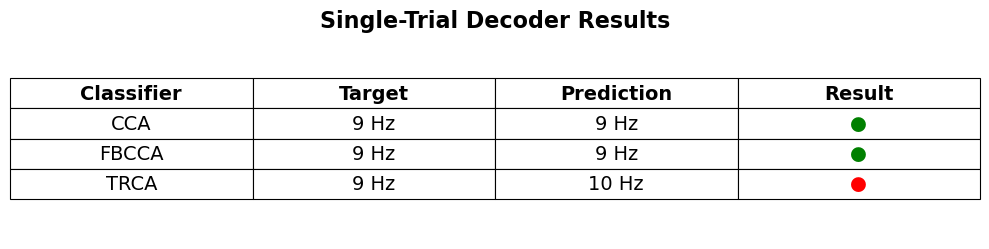

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 2.6))
ax.axis("off")

data = [
    ["CCA",   "9 Hz", "9 Hz",  "x"],
    ["FBCCA", "9 Hz", "9 Hz",  "x"],
    ["TRCA",  "9 Hz", "10 Hz", "x"],
]

cols = ["Classifier", "Target", "Prediction", "Result"]

tbl = ax.table(
    cellText=data,
    colLabels=cols,
    cellLoc="center",
    loc="center"
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(14)
tbl.scale(1, 1.8)

# header
for c in range(len(cols)):
    cell = tbl[(0, c)]
    cell.set_text_props(weight="bold")
    cell.set_linewidth(1.0)

# lighter borders
for key, cell in tbl.get_celld().items():
    cell.set_linewidth(0.8)

# result colors
tbl[(1,3)].get_text().set_color("green")
tbl[(2,3)].get_text().set_color("green")
tbl[(3,3)].get_text().set_color("red")

plt.title("Single-Trial Decoder Results", fontsize=16, weight="semibold", pad=8)

plt.tight_layout()
plt.show()

In [18]:
# Compact clean version

comparison_df = pd.DataFrame([
    ["CCA",   "9 Hz", "9 Hz",  "Correct"],
    ["FBCCA", "9 Hz", "9 Hz",  "Correct"],
    ["TRCA",  "9 Hz", "10 Hz", "Incorrect"],
], columns=["Classifier", "Target", "Prediction", "Result"])

display(
    comparison_df.style
    .hide(axis="index")
    .set_caption("Single-Trial Decoder Comparison")
    .set_properties(**{
        "font-size": "13pt",
        "padding": "4px 10px",
        "text-align": "center",
        "white-space": "nowrap"
    })
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "13pt"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("margin-bottom", "4px"),
                ("white-space", "nowrap")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("font-size", "13pt"),
                ("font-weight", "normal"),
                ("text-align", "center"),
                ("padding", "4px 10px"),
                ("border-bottom", "1px solid #999"),
                ("white-space", "nowrap")
            ]
        }
    ])
)

Classifier,Target,Prediction,Result
CCA,9 Hz,9 Hz,Correct
FBCCA,9 Hz,9 Hz,Correct
TRCA,9 Hz,10 Hz,Incorrect


## Demo Takeaway

On this representative trial, CCA and FBCCA correctly identify the stimulus frequency, while TRCA underperforms on this dataset. This matches our broader benchmark findings.